In [2]:
# ============================================================
# CELL 0: Upload the dataset to Colab
# ============================================================
from google.colab import files

uploaded = files.upload()   # ← A button will appear, click it and select FashionDataset.csv

print("✅ File uploaded successfully!")
print("Files available:", list(uploaded.keys()))

Saving FashionDataset.csv to FashionDataset.csv
✅ File uploaded successfully!
Files available: ['FashionDataset.csv']


In [3]:
# ============================================================
# STEP 1: Load & Explore the Data
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (upload FashionDataset.csv to Colab first)
df = pd.read_csv('FashionDataset.csv')

# Basic info
print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (30758, 8)

Column Names: ['Unnamed: 0', 'BrandName', 'Deatils', 'Sizes', 'MRP', 'SellPrice', 'Discount', 'Category']

First 5 rows:


,Unnamed: 0,BrandName,Deatils,Sizes,MRP,SellPrice,Discount,Category
0,0,life,solid cotton blend collar neck womens a-line d...,"Size:Large,Medium,Small,X-Large,X-Small",Rs\n1699,849,50% off,Westernwear-Women
1,1,only,polyester peter pan collar womens blouson dres...,"Size:34,36,38,40",Rs\n3499,2449,30% off,Westernwear-Women
2,2,fratini,solid polyester blend wide neck womens regular...,"Size:Large,X-Large,XX-Large",Rs\n1199,599,50% off,Westernwear-Women
3,3,zink london,stripes polyester sweetheart neck womens dress...,"Size:Large,Medium,Small,X-Large",Rs\n2299,1379,40% off,Westernwear-Women
4,4,life,regular fit regular length denim womens jeans ...,"Size:26,28,30,32,34,36",Rs\n1699,849,50% off,Westernwear-Women


In [4]:
# Check data types and missing values
print("Data Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

Data Types:
 Unnamed: 0     int64
BrandName     object
Deatils       object
Sizes         object
MRP           object
SellPrice     object
Discount      object
Category      object
dtype: object

Missing Values:
 Unnamed: 0    0
BrandName     0
Deatils       0
Sizes         0
MRP           0
SellPrice     0
Discount      0
Category      0
dtype: int64


In [5]:
# Explore each column
print("Categories:\n", df['Category'].value_counts())
print("\nTop Brands:\n", df['BrandName'].value_counts().head(10))
print("\nDiscount values:\n", df['Discount'].value_counts().head(10))
print("\nSample MRP values:", df['MRP'].head(5).tolist())

Categories:
 Category
Westernwear-Women           10374
Indianwear-Women            10374
Lingerie&Nightwear-Women     3354
Footwear-Women               2574
Watches-Women                1794
Jewellery-Women              1794
Fragrance-Women               494
Name: count, dtype: int64

Top Brands:
 BrandName
vastranand     1543
Nan            1183
zink london     918
global desi     889
stop            884
enamor          790
janasya         751
and             709
faballey        646
life            628
Name: count, dtype: int64

Discount values:
 Discount
Nan        8208
50% off    7605
30% off    2757
60% off    2644
40% off    2189
20% off    1786
55% off    1480
65% off     715
70% off     602
45% off     545
Name: count, dtype: int64

Sample MRP values: ['Rs\n1699', 'Rs\n3499', 'Rs\n1199', 'Rs\n2299', 'Rs\n1699']


In [6]:
# ============================================================
# STEP 2: Data Cleaning
# ============================================================

# --- Fix MRP column (it looks like "Rs\n1699") ---
df['MRP'] = df['MRP'].str.replace('Rs\n', '', regex=False)  # remove "Rs\n"
df['MRP'] = df['MRP'].str.replace(',', '', regex=False)      # remove commas
df['MRP'] = pd.to_numeric(df['MRP'], errors='coerce')        # convert to number

# --- Fix SellPrice column (has "Nan" strings) ---
df['SellPrice'] = df['SellPrice'].replace('Nan', np.nan)
df['SellPrice'] = pd.to_numeric(df['SellPrice'], errors='coerce')

# --- Fix Discount column (looks like "50% off") ---
df['Discount'] = df['Discount'].str.replace('% off', '', regex=False)  # remove "% off"
df['Discount'] = df['Discount'].replace('Nan', np.nan)
df['Discount'] = pd.to_numeric(df['Discount'], errors='coerce')

# --- Drop the useless index column ---
df.drop(columns=['Unnamed: 0'], inplace=True)

# --- Drop rows where SellPrice is missing (our target column) ---
df.dropna(subset=['SellPrice'], inplace=True)

# --- Fill missing Discount with 0 (no discount) ---
df['Discount'].fillna(0, inplace=True)

# --- Fill missing MRP using SellPrice (reasonable guess) ---
df['MRP'].fillna(df['SellPrice'], inplace=True)

print("Cleaned Shape:", df.shape)
print("\nMissing after cleaning:")
print(df.isnull().sum())
print("\nSample cleaned data:")
df.head()

Cleaned Shape: (29575, 7)

Missing after cleaning:
BrandName    0
Deatils      0
Sizes        0
MRP          0
SellPrice    0
Discount     0
Category     0
dtype: int64

Sample cleaned data:


/tmp/ipykernel_6907/462894669.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Discount'].fillna(0, inplace=True)
/tmp/ipykernel_6907/462894669.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

,BrandName,Deatils,Sizes,MRP,SellPrice,Discount,Category
0,life,solid cotton blend collar neck womens a-line d...,"Size:Large,Medium,Small,X-Large,X-Small",1699.0,849.0,50.0,Westernwear-Women
1,only,polyester peter pan collar womens blouson dres...,"Size:34,36,38,40",3499.0,2449.0,30.0,Westernwear-Women
2,fratini,solid polyester blend wide neck womens regular...,"Size:Large,X-Large,XX-Large",1199.0,599.0,50.0,Westernwear-Women
3,zink london,stripes polyester sweetheart neck womens dress...,"Size:Large,Medium,Small,X-Large",2299.0,1379.0,40.0,Westernwear-Women
4,life,regular fit regular length denim womens jeans ...,"Size:26,28,30,32,34,36",1699.0,849.0,50.0,Westernwear-Women


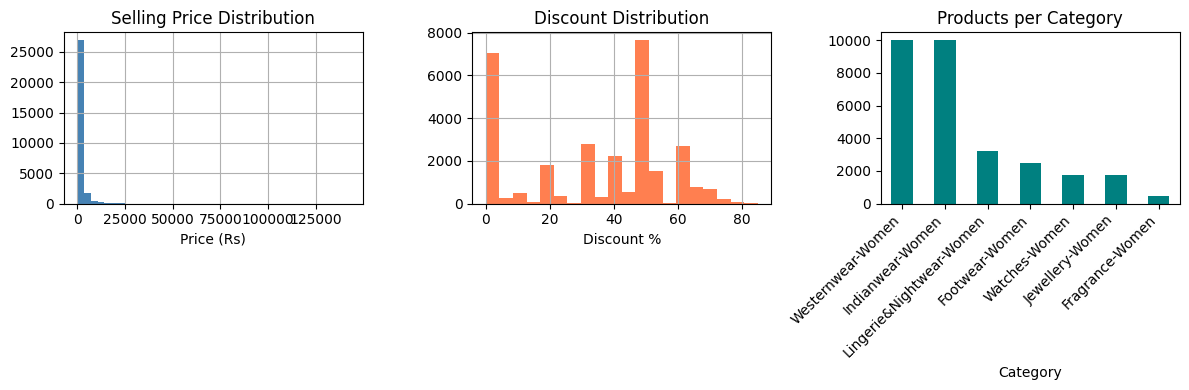

In [7]:
# Visualise the cleaned data
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
df['SellPrice'].hist(bins=40, color='steelblue')
plt.title('Selling Price Distribution')
plt.xlabel('Price (Rs)')

plt.subplot(1, 3, 2)
df['Discount'].hist(bins=20, color='coral')
plt.title('Discount Distribution')
plt.xlabel('Discount %')

plt.subplot(1, 3, 3)
df['Category'].value_counts().plot(kind='bar', color='teal')
plt.title('Products per Category')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# STEP 3: Preprocessing
# ============================================================
from sklearn.preprocessing import LabelEncoder

# We will predict: SellPrice
# Using features: MRP, Discount, BrandName, Category

# Copy only the columns we need
model_df = df[['MRP', 'Discount', 'BrandName', 'Category', 'SellPrice']].copy()

# --- Encode BrandName (text → numbers) ---
le_brand = LabelEncoder()
model_df['BrandName'] = le_brand.fit_transform(model_df['BrandName'])

# --- Encode Category (text → numbers) ---
le_category = LabelEncoder()
model_df['Category'] = le_category.fit_transform(model_df['Category'])

print("After encoding:")
print(model_df.head())
print("\nBrand mapping sample:", dict(zip(le_brand.classes_[:5], le_brand.transform(le_brand.classes_[:5]))))
print("Category mapping:", dict(zip(le_category.classes_, le_category.transform(le_category.classes_))))

After encoding:
      MRP  Discount  BrandName  Category  SellPrice
0  1699.0      50.0        154         6      849.0
1  3499.0      30.0        186         6     2449.0
2  1199.0      50.0         95         6      599.0
3  2299.0      40.0        270         6     1379.0
4  1699.0      50.0        154         6      849.0

Brand mapping sample: {'109f': np.int64(0), '18.21 man made': np.int64(1), '4711': np.int64(2), 'aarke': np.int64(3), 'abercrombie & fitch': np.int64(4)}
Category mapping: {'Footwear-Women': np.int64(0), 'Fragrance-Women': np.int64(1), 'Indianwear-Women': np.int64(2), 'Jewellery-Women': np.int64(3), 'Lingerie&Nightwear-Women': np.int64(4), 'Watches-Women': np.int64(5), 'Westernwear-Women': np.int64(6)}


In [9]:
# --- Split into Features (X) and Target (y) ---
X = model_df.drop(columns=['SellPrice'])   # everything except price
y = model_df['SellPrice']                  # price is what we predict

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())

Features shape: (29575, 4)
Target shape: (29575,)

Feature columns: ['MRP', 'Discount', 'BrandName', 'Category']


In [10]:
# --- Train/Test Split ---
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42     # so results are reproducible
)

print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])

Training samples: 23660
Testing samples:  5915


In [11]:
# ============================================================
# STEP 4: Train the Model
# ============================================================
from sklearn.ensemble import RandomForestRegressor

# Create the model
model = RandomForestRegressor(
    n_estimators=100,    # 100 decision trees
    random_state=42
)

# Train it
print("Training model... (this may take 1-2 minutes)")
model.fit(X_train, y_train)
print("✅ Model trained!")

Training model... (this may take 1-2 minutes)
✅ Model trained!


In [12]:
# ============================================================
# STEP 5: Evaluate the Model
# ============================================================
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE) : Rs {mae:.2f}")
print(f"Root Mean Sq. Error (RMSE): Rs {rmse:.2f}")
print(f"R² Score                  : {r2:.4f}")
print(f"\n→ On average, our prediction is off by Rs {mae:.0f}")

Mean Absolute Error (MAE) : Rs 9.21
Root Mean Sq. Error (RMSE): Rs 233.51
R² Score                  : 0.9955

→ On average, our prediction is off by Rs 9


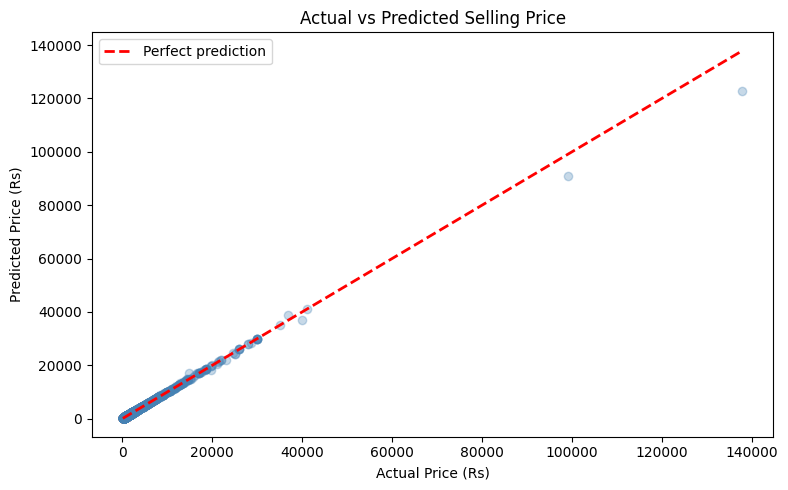

In [13]:
# Visualise actual vs predicted prices
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Price (Rs)')
plt.ylabel('Predicted Price (Rs)')
plt.title('Actual vs Predicted Selling Price')
plt.legend()
plt.tight_layout()
plt.show()

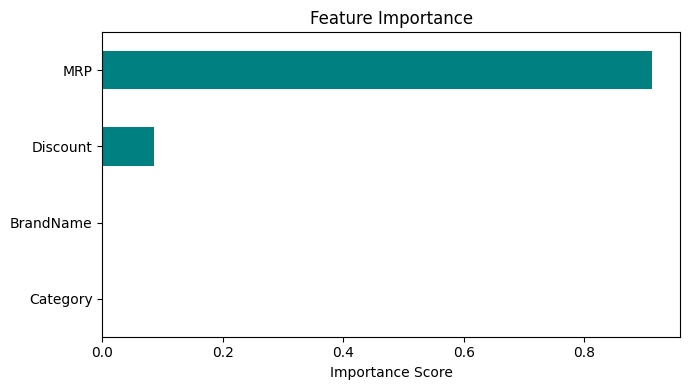

In [14]:
# Feature importance — which column matters most?
feat_imp = pd.Series(model.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', color='teal', figsize=(7, 4))
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# STEP 6A: Save the model and encoders
# ============================================================
import pickle

# Save everything we need for the app
with open('fashion_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('brand_encoder.pkl', 'wb') as f:
    pickle.dump(le_brand, f)

with open('category_encoder.pkl', 'wb') as f:
    pickle.dump(le_category, f)

print("✅ Model saved as fashion_model.pkl")
print("✅ Encoders saved!")

# Download the files from Colab to your computer
from google.colab import files
files.download('fashion_model.pkl')
files.download('brand_encoder.pkl')
files.download('category_encoder.pkl')

✅ Model saved as fashion_model.pkl
✅ Encoders saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>